# Data Cleaning & Preparation

Este notebook realiza la limpieza, transformación e integración de múltiples datasets para generar un dataset final listo para análisis.

In [2]:
import pandas as pd
import numpy as np

## Limpieza - GDP per capita

In [3]:
df_gdp = pd.read_csv("API_NY.GDP.PCAP.CD_DS2_en_csv_v2_121663.csv", skiprows=4)
df_gdp.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,GDP per capita (current US$),NY.GDP.PCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,28440.041688,30082.158423,30645.890602,22759.807175,26749.329609,30975.998912,35718.753119,39498.594129,NaN,NaN
1,Africa Eastern and Southern,AFE,GDP per capita (current US$),NY.GDP.PCAP.CD,186.089204,186.909053,197.367547,225.400079,208.962717,226.836135,...,1528.104224,1552.073722,1507.085600,1351.591669,1562.416175,1679.327622,1571.449189,1615.396356,NaN,NaN
2,Afghanistan,AFG,GDP per capita (current US$),NY.GDP.PCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,525.469771,491.337221,496.602504,510.787063,356.496214,357.261153,413.757895,NaN,NaN,NaN
3,Africa Western and Central,AFW,GDP per capita (current US$),NY.GDP.PCAP.CD,121.936832,127.451040,133.823783,139.004980,148.545883,155.561897,...,1574.230564,1720.140092,2216.385055,2030.861659,2112.794076,2138.473153,1841.855064,1411.337029,NaN,NaN
4,Angola,AGO,GDP per capita (current US$),NY.GDP.PCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,2790.718869,2860.093648,2493.678844,1759.356199,2303.908127,3682.113151,2916.136633,2665.874448,NaN,NaN


In [4]:
df_gdp.shape
df_gdp.columns
df_gdp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 266 entries, 0 to 265
Data columns (total 71 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country Name    266 non-null    object 
 1   Country Code    266 non-null    object 
 2   Indicator Name  266 non-null    object 
 3   Indicator Code  266 non-null    object 
 4   1960            151 non-null    float64
 5   1961            154 non-null    float64
 6   1962            156 non-null    float64
 7   1963            156 non-null    float64
 8   1964            156 non-null    float64
 9   1965            162 non-null    float64
 10  1966            163 non-null    float64
 11  1967            167 non-null    float64
 12  1968            168 non-null    float64
 13  1969            168 non-null    float64
 14  1970            190 non-null    float64
 15  1971            191 non-null    float64
 16  1972            191 non-null    float64
 17  1973            191 non-null    flo

In [5]:
df_gdp_long = df_gdp.melt(
    id_vars=['Country Name', 'Country Code'],
    var_name='year',
    value_name='gdp_per_capita'
)

df_gdp_long.head()

,Country Name,Country Code,year,gdp_per_capita
0,Aruba,ABW,Indicator Name,GDP per capita (current US$)
1,Africa Eastern and Southern,AFE,Indicator Name,GDP per capita (current US$)
2,Afghanistan,AFG,Indicator Name,GDP per capita (current US$)
3,Africa Western and Central,AFW,Indicator Name,GDP per capita (current US$)
4,Angola,AGO,Indicator Name,GDP per capita (current US$)


In [6]:
df_gdp_long = df_gdp_long.dropna(subset=['gdp_per_capita'])

In [7]:
df_gdp_long['year'] = pd.to_numeric(df_gdp_long['year'], errors='coerce')

In [8]:
df_gdp_long = df_gdp_long.dropna(subset=['year'])

In [9]:
df_gdp_long['year'] = df_gdp_long['year'].astype(int)

In [10]:
df_gdp_long.head()


,Country Name,Country Code,year,gdp_per_capita
533,Africa Eastern and Southern,AFE,1960,186.089204
535,Africa Western and Central,AFW,1960,121.936832
541,Argentina,ARG,1960,778.251707
545,Australia,AUS,1960,1813.431099
546,Austria,AUT,1960,939.914815


In [11]:
df_gdp_long = df_gdp_long.rename(columns={
    'Country Name': 'country',
    'Country Code': 'country_code'
})

In [12]:
df_gdp_long['gdp_per_capita'] = pd.to_numeric(
    df_gdp_long['gdp_per_capita'],
    errors='coerce'
)

In [13]:
df_gdp_long = df_gdp_long.dropna(subset=['gdp_per_capita'])

In [14]:
df_gdp_long.duplicated().sum()

np.int64(0)

In [15]:
df_gdp_long.describe()

,year,gdp_per_capita
count,14561.000000,14561.000000
mean,1994.830575,8701.887816
std,18.108603,17595.339722
min,1960.000000,11.801322
25%,1980.000000,583.782776
50%,1996.000000,1938.810849
75%,2010.000000,8045.946305
max,2024.000000,288001.433369


In [16]:
df_gdp_long.info()
df_gdp_long.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 14561 entries, 533 to 17821
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   country         14561 non-null  object 
 1   country_code    14561 non-null  object 
 2   year            14561 non-null  int64  
 3   gdp_per_capita  14561 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 568.8+ KB


,year,gdp_per_capita
count,14561.000000,14561.000000
mean,1994.830575,8701.887816
std,18.108603,17595.339722
min,1960.000000,11.801322
25%,1980.000000,583.782776
50%,1996.000000,1938.810849
75%,2010.000000,8045.946305
max,2024.000000,288001.433369


<Axes: xlabel='year'>

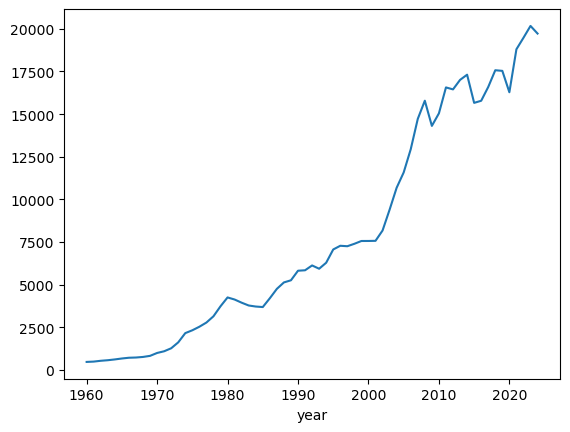

In [17]:
df_gdp_long.groupby('year')['gdp_per_capita'].mean().plot()

## Limpieza - Expectativa de vida

In [18]:
df_life = pd.read_csv("API_SP.DYN.LE00.IN_DS2_en_csv_v2_121663.csv", skiprows=4)
df_gdp.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,GDP per capita (current US$),NY.GDP.PCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,28440.041688,30082.158423,30645.890602,22759.807175,26749.329609,30975.998912,35718.753119,39498.594129,NaN,NaN
1,Africa Eastern and Southern,AFE,GDP per capita (current US$),NY.GDP.PCAP.CD,186.089204,186.909053,197.367547,225.400079,208.962717,226.836135,...,1528.104224,1552.073722,1507.085600,1351.591669,1562.416175,1679.327622,1571.449189,1615.396356,NaN,NaN
2,Afghanistan,AFG,GDP per capita (current US$),NY.GDP.PCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,525.469771,491.337221,496.602504,510.787063,356.496214,357.261153,413.757895,NaN,NaN,NaN
3,Africa Western and Central,AFW,GDP per capita (current US$),NY.GDP.PCAP.CD,121.936832,127.451040,133.823783,139.004980,148.545883,155.561897,...,1574.230564,1720.140092,2216.385055,2030.861659,2112.794076,2138.473153,1841.855064,1411.337029,NaN,NaN
4,Angola,AGO,GDP per capita (current US$),NY.GDP.PCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,2790.718869,2860.093648,2493.678844,1759.356199,2303.908127,3682.113151,2916.136633,2665.874448,NaN,NaN


In [19]:
df_life_long = df_life.melt(
    id_vars=['Country Name', 'Country Code'],
    var_name='year',
    value_name='life_expectancy'
)

In [20]:
df_life_long = df_life_long.dropna(subset=['life_expectancy'])

df_life_long['year'] = pd.to_numeric(df_life_long['year'], errors='coerce')

df_life_long = df_life_long.dropna(subset=['year'])

df_life_long['year'] = df_life_long['year'].astype(int)

df_life_long.head()

,Country Name,Country Code,year,life_expectancy
532,Aruba,ABW,1960,64.049
533,Africa Eastern and Southern,AFE,1960,44.169658
534,Afghanistan,AFG,1960,32.799
535,Africa Western and Central,AFW,1960,37.779636
536,Angola,AGO,1960,37.933


In [21]:
df_life_long = df_life_long.rename(columns={
    'Country Name': 'country',
    'Country Code': 'country_code'
})

df_life_long.head()

,country,country_code,year,life_expectancy
532,Aruba,ABW,1960,64.049
533,Africa Eastern and Southern,AFE,1960,44.169658
534,Afghanistan,AFG,1960,32.799
535,Africa Western and Central,AFW,1960,37.779636
536,Angola,AGO,1960,37.933


In [22]:
df_life_long.info()
df_life_long.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 17191 entries, 532 to 17821
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   country          17191 non-null  object
 1   country_code     17191 non-null  object
 2   year             17191 non-null  int64 
 3   life_expectancy  17191 non-null  object
dtypes: int64(1), object(3)
memory usage: 671.5+ KB


,year
count,17191.000000
mean,1992.037287
std,18.757761
min,1960.000000
25%,1976.000000
50%,1992.000000
75%,2008.000000
max,2024.000000


In [23]:
df_life_long['life_expectancy'].unique()[:10]

array([64.049, 44.169658253166, 32.799, 37.779636388716, 37.933, 56.413,
       72.094, 44.7940556740454, 50.651, 64.242], dtype=object)

In [24]:
df_life_long['life_expectancy'] = pd.to_numeric(
    df_life_long['life_expectancy'],
    errors='coerce'
)

In [25]:
df_life_long = df_life_long.dropna(subset=['life_expectancy'])

In [26]:
df_life_long.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17191 entries, 532 to 17821
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   country          17191 non-null  object 
 1   country_code     17191 non-null  object 
 2   year             17191 non-null  int64  
 3   life_expectancy  17191 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 671.5+ KB


In [27]:
df_merged = pd.merge(
    df_gdp_long,
    df_life_long,
    on=['country', 'country_code', 'year'],
    how='inner'
)

In [28]:
df_merged.head()
df_merged.shape

(14557, 5)

In [29]:
df_merged.head()

,country,country_code,year,gdp_per_capita,life_expectancy
0,Africa Eastern and Southern,AFE,1960,186.089204,44.169658
1,Africa Western and Central,AFW,1960,121.936832,37.779636
2,Argentina,ARG,1960,778.251707,64.242000
3,Australia,AUS,1960,1813.431099,70.817073
4,Austria,AUT,1960,939.914815,68.585610


In [30]:
df_gdp_long.shape
df_life_long.shape
df_merged.shape

(14557, 5)

In [31]:
df_merged.isna().sum()

country            0
country_code       0
year               0
gdp_per_capita     0
life_expectancy    0
dtype: int64

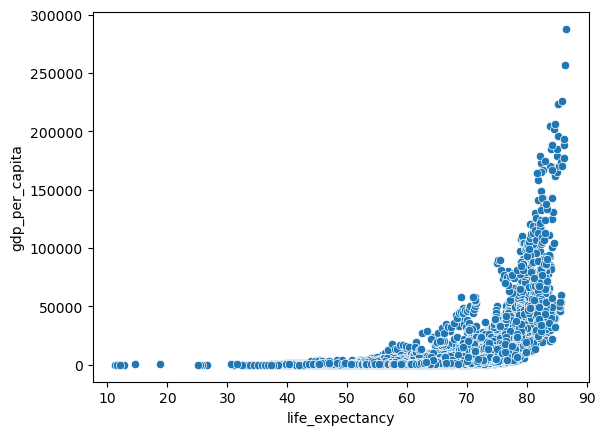

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(
    data=df_merged,
    x='life_expectancy',
    y='gdp_per_capita'
)

plt.show()

## Limpieza - Uso de internet

In [33]:
df_int = pd.read_csv("API_IT.NET.USER.ZS_DS2_en_csv_v2_121585.csv", skiprows=4)
df_int.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,Individuals using the Internet (% of population),IT.NET.USER.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,97.17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Africa Eastern and Southern,AFE,Individuals using the Internet (% of population),IT.NET.USER.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,17.30,19.600000,21.600000,23.5000,25.000000,26.800000,27.800000,28.800000,30.4,NaN
2,Afghanistan,AFG,Individuals using the Internet (% of population),IT.NET.USER.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,13.50,16.799999,17.600000,17.0485,16.514299,15.866300,15.928400,16.094999,NaN,NaN
3,Africa Western and Central,AFW,Individuals using the Internet (% of population),IT.NET.USER.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,23.80,25.700000,28.500000,31.5000,34.700000,37.500000,38.500000,40.000000,42.4,NaN
4,Angola,AGO,Individuals using the Internet (% of population),IT.NET.USER.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,26.00,29.000000,32.129398,33.3209,34.556499,35.838001,37.885899,40.704800,NaN,NaN


In [34]:
df_int_long = df_int.melt(
    id_vars=['Country Name', 'Country Code'],
    var_name='year',
    value_name='internet_usage'
)

In [35]:
df_int_long = df_int_long.dropna(subset=['internet_usage'])

df_int_long['year'] = pd.to_numeric(df_int_long['year'], errors='coerce')

df_int_long = df_int_long.dropna(subset=['year'])

df_int_long['year'] = df_int_long['year'].astype(int)

df_int_long.head()

,Country Name,Country Code,year,internet_usage
8512,Aruba,ABW,1990,0.0
8514,Afghanistan,AFG,1990,0.0
8516,Angola,AGO,1990,0.0
8517,Albania,ALB,1990,0.0
8518,Andorra,AND,1990,0.0


In [36]:
df_int_long = df_int_long.rename(columns={
    'Country Name': 'country',
    'Country Code': 'country_code'
})

df_int_long.head()

,country,country_code,year,internet_usage
8512,Aruba,ABW,1990,0.0
8514,Afghanistan,AFG,1990,0.0
8516,Angola,AGO,1990,0.0
8517,Albania,ALB,1990,0.0
8518,Andorra,AND,1990,0.0


In [37]:
df_int_long.info()
df_int_long.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 6917 entries, 8512 to 18081
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   country         6917 non-null   object
 1   country_code    6917 non-null   object
 2   year            6917 non-null   int64 
 3   internet_usage  6917 non-null   object
dtypes: int64(1), object(3)
memory usage: 270.2+ KB


,year
count,6917.000000
mean,2008.963423
std,9.335899
min,1990.000000
25%,2002.000000
50%,2009.000000
75%,2017.000000
max,2025.000000


In [38]:
df_int_long['internet_usage'].unique()[:10]

array([0.0, 0.585, 0.13, 0.00101, 0.361, 0.596, 0.126, 0.0973, 0.0129,
       0.401], dtype=object)

In [39]:
df_int_long['internet_usage'] = pd.to_numeric(
    df_int_long['internet_usage'],
    errors='coerce'
)

In [40]:
df_int_long = df_int_long.dropna(subset=['internet_usage'])

In [41]:
df_int_long.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6917 entries, 8512 to 18081
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   country         6917 non-null   object 
 1   country_code    6917 non-null   object 
 2   year            6917 non-null   int64  
 3   internet_usage  6917 non-null   float64
dtypes: float64(1), int64(1), object(2)
memory usage: 270.2+ KB


In [42]:
df_merged = pd.merge(
    df_merged,
    df_int_long,
    on=['country', 'country_code', 'year'],
    how='inner'
)

In [43]:
df_merged.isna().sum()

country            0
country_code       0
year               0
gdp_per_capita     0
life_expectancy    0
internet_usage     0
dtype: int64

In [44]:
df_merged.head()

,country,country_code,year,gdp_per_capita,life_expectancy,internet_usage
0,Aruba,ABW,1990,12187.536361,72.546,0.0
1,Angola,AGO,1990,965.866840,41.854,0.0
2,Albania,ALB,1990,617.230436,72.710,0.0
3,Andorra,AND,1990,19563.657472,78.961,0.0
4,United Arab Emirates,ARE,1990,26709.993440,71.074,0.0


In [45]:
df_merged.shape

(6777, 6)

<Axes: xlabel='internet_usage', ylabel='gdp_per_capita'>

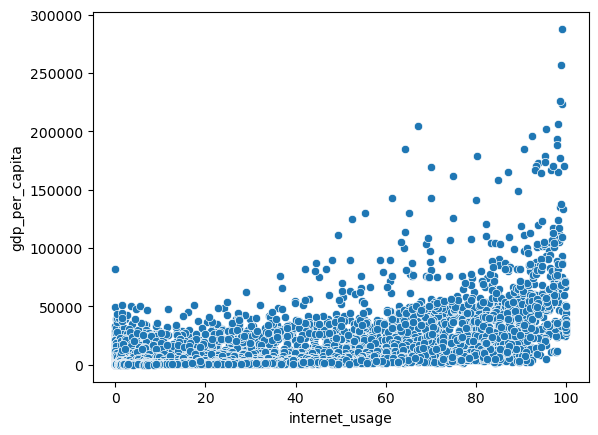

In [46]:
import seaborn as sns

sns.scatterplot(
    data=df_merged,
    x='internet_usage',
    y='gdp_per_capita'
)

## Limpieza - Desempleo

In [47]:
df_uem = pd.read_csv("API_SL.UEM.TOTL.NE.ZS_DS2_en_csv_v2_2004.csv", skiprows=4)
df_uem.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,"Unemployment, total (% of total labor force) (...",SL.UEM.TOTL.NE.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Africa Eastern and Southern,AFE,"Unemployment, total (% of total labor force) (...",SL.UEM.TOTL.NE.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,AFG,"Unemployment, total (% of total labor force) (...",SL.UEM.TOTL.NE.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,11.184000,NaN,NaN,11.710,5.679,NaN,NaN,NaN,NaN,NaN
3,Africa Western and Central,AFW,"Unemployment, total (% of total labor force) (...",SL.UEM.TOTL.NE.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,7.240084,NaN,3.689777,NaN,NaN,3.337512,NaN,NaN,NaN,NaN
4,Angola,AGO,"Unemployment, total (% of total labor force) (...",SL.UEM.TOTL.NE.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,16.431000,16.033,15.806,14.094000,12.885,13.937,NaN,NaN


In [48]:
df_uem_long = df_uem.melt(
    id_vars=['Country Name', 'Country Code'],
    var_name='year',
    value_name='unemployment'
)

In [49]:
df_uem_long = df_uem_long.dropna(subset=['unemployment'])

df_uem_long['year'] = pd.to_numeric(df_uem_long['year'], errors='coerce')

df_uem_long = df_uem_long.dropna(subset=['year'])

df_uem_long['year'] = df_uem_long['year'].astype(int)

df_uem_long.head()

,Country Name,Country Code,year,unemployment
651,Japan,JPN,1960,1.7
783,United States,USA,1960,5.5
917,Japan,JPN,1961,1.4
1049,United States,USA,1961,6.7
1183,Japan,JPN,1962,1.3


In [50]:
df_uem_long = df_uem_long.rename(columns={
    'Country Name': 'country',
    'Country Code': 'country_code'
})

df_int_long.head()

,country,country_code,year,internet_usage
8512,Aruba,ABW,1990,0.0
8514,Afghanistan,AFG,1990,0.0
8516,Angola,AGO,1990,0.0
8517,Albania,ALB,1990,0.0
8518,Andorra,AND,1990,0.0


In [51]:
df_uem_long['unemployment'].unique()[:10]

array([1.7, 5.5, 1.4, 6.7, 1.3, 5.7, 1.1, 5.2, 1.2, 4.5], dtype=object)

In [52]:
df_uem_long['unemployment'] = pd.to_numeric(
    df_uem_long['unemployment'],
    errors='coerce'
)

df_uem_long = df_uem_long.dropna(subset=['unemployment'])

In [53]:
df_uem_long.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5962 entries, 651 to 18073
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   country       5962 non-null   object 
 1   country_code  5962 non-null   object 
 2   year          5962 non-null   int64  
 3   unemployment  5962 non-null   float64
dtypes: float64(1), int64(1), object(2)
memory usage: 232.9+ KB


In [54]:
df_merged = pd.merge(
    df_merged,
    df_uem_long,
    on=['country', 'country_code', 'year'],
    how='inner'
)

df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4107 entries, 0 to 4106
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   country          4107 non-null   object 
 1   country_code     4107 non-null   object 
 2   year             4107 non-null   int64  
 3   gdp_per_capita   4107 non-null   float64
 4   life_expectancy  4107 non-null   float64
 5   internet_usage   4107 non-null   float64
 6   unemployment     4107 non-null   float64
dtypes: float64(4), int64(1), object(2)
memory usage: 224.7+ KB


In [55]:
df_merged.head()

,country,country_code,year,gdp_per_capita,life_expectancy,internet_usage,unemployment
0,Albania,ALB,1990,617.230436,72.710000,0.000,9.500
1,Argentina,ARG,1990,4315.334031,71.615000,0.000,7.058
2,Australia,AUS,1990,18273.561526,76.994634,0.585,6.926
3,Austria,AUT,1990,21596.068220,75.568293,0.130,3.233
4,Burundi,BDI,1990,202.629446,45.184000,0.000,0.476


## Dataset final

In [59]:
df_merged.info()
df_merged.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4107 entries, 0 to 4106
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   country          4107 non-null   object 
 1   country_code     4107 non-null   object 
 2   year             4107 non-null   int64  
 3   gdp_per_capita   4107 non-null   float64
 4   life_expectancy  4107 non-null   float64
 5   internet_usage   4107 non-null   float64
 6   unemployment     4107 non-null   float64
dtypes: float64(4), int64(1), object(2)
memory usage: 224.7+ KB


,country,country_code,year,gdp_per_capita,life_expectancy,internet_usage,unemployment
0,Albania,ALB,1990,617.230436,72.710000,0.000,9.500
1,Argentina,ARG,1990,4315.334031,71.615000,0.000,7.058
2,Australia,AUS,1990,18273.561526,76.994634,0.585,6.926
3,Austria,AUT,1990,21596.068220,75.568293,0.130,3.233
4,Burundi,BDI,1990,202.629446,45.184000,0.000,0.476
